In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [4]:
folder_path = "/kaggle/input/radar-obd-ii-dataset"
file_extension = "csv"

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import glob

### Define function to count the files
def count_files(folder_path, file_extension):
    # Create a file path pattern using glob
    pattern = os.path.join(folder_path, f"*.{file_extension}")

    # Use glob to get a list of files matching the pattern
    files = glob.glob(pattern)

    # Return the count of matching files
    return len(files)




count = count_files(folder_path, file_extension)
print(f"Number of {file_extension} files in {folder_path} is: {count}")

Number of csv files in /kaggle/input/radar-obd-ii-dataset is: 81


In [6]:
def identify_unique_path(folder_path):
    travel_path = []
    origin = []
    destination = []
    pattern = os.path.join(folder_path, f"*.csv")
    filenames = glob.glob(pattern)

    for filename in filenames:
        components = filename.split('_')
        origin.append(components[3])
        destination.append(components[4])
        travel_path.append(components[3] + '_' + components[4])
        
    unique_origin = set(origin)
    unique_destination = set(destination)
    unique_path = set(travel_path)
    
    return {
        "Origin": origin,
        "Destination": destination,
        "Travel Path": travel_path,
        "Unique Origin": set(origin),
        "Unique Destination": set(destination),
        "Summary": f"The dataset contains {len(unique_origin)} origin, {len(unique_destination)} destination and {len(unique_path)} unique paths"
    }

print(identify_unique_path(folder_path))

{'Origin': ['S', 'RT', 'RT', 'RT', 'KA', 'KA', 'S', 'S', 'KA', 'KA', 'KA', 'KA', 'RT', 'KA', 'RT', 'S', 'RT', 'RT', 'S', 'RT', 'KA', 'KA', 'KA', 'KA', 'RT', 'KA', 'KA', 'RT', 'KA', 'S', 'S', 'RT', 'S', 'S', 'S', 'RT', 'S', 'KA', 'S', 'RT', 'RT', 'S', 'KA', 'RT', 'KA', 'KA', 'KA', 'KA', 'S', 'KA', 'RT', 'BB', 'RT', 'RT', 'S', 'RT', 'S', 'KA', 'S', 'RT', 'RT', 'RT', 'KA', 'S', 'KA', 'RT', 'BB', 'S', 'KA', 'RT', 'RT', 'RT', 'KA', 'S', 'RT', 'KA', 'KA', 'S', 'RT', 'RT', 'RT'], 'Destination': ['RT', 'RT', 'S', 'KA', 'RT', 'KA', 'RT', 'RT', 'KA', 'KA', 'RT', 'KA', 'S', 'RT', 'S', 'RT', 'S', 'RT', 'RT', 'S', 'KA', 'RT', 'KA', 'KA', 'KA', 'KA', 'S', 'KA', 'KA', 'CW', 'RT', 'S', 'RT', 'RT', 'RT', 'S', 'RT', 'KA', 'RT', 'S', 'S', 'RT', 'RT', 'S', 'BB', 'KA', 'RT', 'KA', 'RT', 'KA', 'S', 'RT', 'KA', 'S', 'RT', 'KA', 'S', 'KA', 'KA', 'KA', 'S', 'KA', 'KA', 'RT', 'KA', 'S', 'RT', 'RT', 'RT', 'BB', 'S', 'S', 'RT', 'RT', 'S', 'RT', 'KA', 'KA', 'KA', 'S', 'S'], 'Travel Path': ['S_RT', 'RT_RT', 'RT_S',

In [7]:
groups = {"normal": [], "free": [], "busy": [], "unknown": []}

In [8]:
def check_condition(folder_path,groups):
    n_free,n_normal,n_busy = 0,0,0
    file_pattern = os.path.join(folder_path, f"*.csv")
    filenames = glob.glob(file_pattern)
    
    for filename in filenames:
        if "Frei" in filename:
            n_free += 1
            groups["free"].append(filename)
        elif "Normal" in filename:
            n_normal += 1
            groups["normal"].append(filename)
        elif "Stau" in filename:
            n_busy += 1
            groups["busy"].append(filename)

    return {
        "Free condition": n_free,
        "Normal": n_normal,
        "Busy": n_busy
    }

def read_csv_robust(path):
    
    return pd.read_csv(path)

def load_group(paths, label):
    frames = []
    for p in paths:
        try:
            df_i = read_csv_robust(p)
            df_i["condition"] = label
            frames.append(df_i)
        except Exception as e:
            print(f"[WARN] {p}: {e}")
    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()


In [9]:
groups = {"normal": [], "free": [], "busy": [], "unknown": []}

In [10]:

print(check_condition(folder_path,groups))
print({k: len(v) for k,v in groups.items()}) 

df_normal = load_group(groups["normal"], "normal")
df_free   = load_group(groups["free"],   "free")
df_busy   = load_group(groups["busy"],   "busy")

df_all = pd.concat([df_normal, df_free, df_busy], ignore_index=True)
print("Shapes:", df_normal.shape, df_free.shape, df_busy.shape, "ALL:", df_all.shape)


{'Free condition': 14, 'Normal': 56, 'Busy': 11}
{'normal': 56, 'free': 14, 'busy': 11, 'unknown': 0}
Shapes: (1975592, 15) (238158, 15) (480074, 15) ALL: (2693824, 15)


In [11]:
def coalesce(df, good, bads):
    for b in bads:
        if b in df.columns:
            if good in df.columns:
                df[good] = df[good].combine_first(df[b])
            else:
                df[good] = df[b]
            df.drop(columns=[b], inplace=True)


def fix_units(df):
    """Apply coalesce for all temperature columns with weird encodings."""
    coalesce(df, "Engine Coolant Temperature [°C]", ["Engine Coolant Temperature [Â°C]", "Engine Coolant Temperature [Ã‚Â°C]"])
    coalesce(df, "Intake Air Temperature [°C]",      ["Intake Air Temperature [Â°C]", "Intake Air Temperature [Ã‚Â°C]"])
    coalesce(df, "Ambient Air Temperature [°C]",     ["Ambient Air Temperature [Â°C]", "Ambient Air Temperature [Ã‚Â°C]"])
    return df

In [12]:
print("Shapes:", df_normal.shape, df_free.shape, df_busy.shape, "ALL:", df_all.shape)

Shapes: (1975592, 15) (238158, 15) (480074, 15) ALL: (2693824, 15)


In [13]:
BACKBONE_FEATURES = [
    'Engine Coolant Temperature [°C]',
    'Intake Manifold Absolute Pressure [kPa]',
    'Engine RPM [RPM]',
    'Intake Air Temperature [°C]',
    'Air Flow Rate from Mass Flow Sensor [g/s]',
    'Absolute Throttle Position [%]',
    'Ambient Air Temperature [°C]'
]


In [14]:
SEQ_LEN = 50
HOP = 5
def create_sequences(data, seq_len=50, hop=5):
    seqs = []
    for i in range(0, len(data) - seq_len, hop):
        seqs.append(data[i:i+seq_len])
    return np.array(seqs)


In [15]:

trip_files = sorted(glob.glob(os.path.join(folder_path, "*.csv")))

In [16]:
from sklearn.preprocessing import MinMaxScaler

In [17]:
def preprocess_trip(df, features):
    """
    Cleans a trip DataFrame:
    - Fixes unit encodings (Â°C → °C)
    - Converts columns to numeric
    - Handles zeros & NaNs
    - Ensures consistent numeric dtypes
    """
    df = fix_units(df)

    # Ensure all features exist
    missing = [c for c in features if c not in df.columns]
    if missing:
        print(f"[WARN] Missing columns: {missing}")
        return None

    # Convert all features to numeric
    df[features] = df[features].apply(pd.to_numeric, errors="coerce").astype(float)

    # Replace zero spikes with NaN, infer numeric dtype, interpolate
   
    df[features] = df[features].infer_objects(copy=False)
    df[features] = df[features].replace(0, np.nan)

    # --- Interpolate *only* the feature subset ---
    df[features] = df[features].interpolate(method='linear').ffill().bfill()
   

    return df[features]


In [18]:
scaler = MinMaxScaler()
all_trips = []

# -------------------------
# 1st PASS → Fit scaler globally
# -------------------------
for f in trip_files:
    df = pd.read_csv(f)
    df.head(10)
    df = preprocess_trip(df, BACKBONE_FEATURES)

    if df is None:
        continue

    scaler.partial_fit(df)

# -------------------------
# 2nd PASS → Transform + sequence creation
# -------------------------
all_trips = []
for f in trip_files:
    df = pd.read_csv(f)
    df = preprocess_trip(df, BACKBONE_FEATURES)
    if df is None:
        print(f"[SKIP] {os.path.basename(f)} missing required features.")
        continue

    df_scaled = pd.DataFrame(
        scaler.transform(df),
        columns=BACKBONE_FEATURES
    )

    # Create LSTM windows
    seqs = create_sequences(df_scaled.values, SEQ_LEN, HOP)
    if len(seqs) == 0:
        print(f"[SKIP] {os.path.basename(f)} too short for {SEQ_LEN}-step windows.")
        continue

    all_trips.append(seqs)

# -------------------------
# FINAL CONCATENATION
# -------------------------
if all_trips:
    X = np.concatenate(all_trips, axis=0)
    print("✅ Final X shape:", X.shape)



✅ Final X shape: (537986, 50, 7)


In [20]:
if all_trips:
    X = np.concatenate(all_trips, axis=0)
    print("✅ Final X shape:", X.shape)


✅ Final X shape: (537986, 50, 7)


In [21]:
for i, seqs in enumerate(all_trips):
    print(f"Trip {i+1}: {seqs.shape}")


Trip 1: (9260, 50, 7)
Trip 2: (6154, 50, 7)
Trip 3: (3613, 50, 7)
Trip 4: (11440, 50, 7)
Trip 5: (7606, 50, 7)
Trip 6: (5452, 50, 7)
Trip 7: (2904, 50, 7)
Trip 8: (3577, 50, 7)
Trip 9: (8200, 50, 7)
Trip 10: (5613, 50, 7)
Trip 11: (8641, 50, 7)
Trip 12: (6465, 50, 7)
Trip 13: (2234, 50, 7)
Trip 14: (11917, 50, 7)
Trip 15: (1356, 50, 7)
Trip 16: (10798, 50, 7)
Trip 17: (10964, 50, 7)
Trip 18: (9460, 50, 7)
Trip 19: (4314, 50, 7)
Trip 20: (3383, 50, 7)
Trip 21: (2707, 50, 7)
Trip 22: (2774, 50, 7)
Trip 23: (14630, 50, 7)
Trip 24: (2118, 50, 7)
Trip 25: (11457, 50, 7)
Trip 26: (2892, 50, 7)
Trip 27: (9550, 50, 7)
Trip 28: (7695, 50, 7)
Trip 29: (5098, 50, 7)
Trip 30: (6571, 50, 7)
Trip 31: (7084, 50, 7)
Trip 32: (5465, 50, 7)
Trip 33: (7812, 50, 7)
Trip 34: (4897, 50, 7)
Trip 35: (4879, 50, 7)
Trip 36: (7723, 50, 7)
Trip 37: (5602, 50, 7)
Trip 38: (5885, 50, 7)
Trip 39: (3919, 50, 7)
Trip 40: (6185, 50, 7)
Trip 41: (5211, 50, 7)
Trip 42: (5598, 50, 7)
Trip 43: (8313, 50, 7)
Trip 44: (5859

In [22]:
df_raw = pd.read_csv(trip_files[1])
print(df_raw['Time'].head(10).tolist())

# keep time for plotting
if 'Time' in df_raw.columns:
    df_raw['Time'] = pd.to_datetime(df_raw['Time'],format="%H:%M:%S.%f", errors='coerce')

df_clean = preprocess_trip(df_raw, BACKBONE_FEATURES)
print(df_raw['Time'].head(10))
print(len(df_raw['Time']), len(df_clean))


['19:17:19.418', '19:17:19.508', '19:17:19.598', '19:17:19.688', '19:17:19.779', '19:17:19.868', '19:17:19.958', '19:17:20.048', '19:17:20.138', '19:17:20.228']
0   1900-01-01 19:17:19.418
1   1900-01-01 19:17:19.508
2   1900-01-01 19:17:19.598
3   1900-01-01 19:17:19.688
4   1900-01-01 19:17:19.779
5   1900-01-01 19:17:19.868
6   1900-01-01 19:17:19.958
7   1900-01-01 19:17:20.048
8   1900-01-01 19:17:20.138
9   1900-01-01 19:17:20.228
Name: Time, dtype: datetime64[ns]
30817 30817


In [23]:
# Make sure Time is parsed (you’ve already done this)
df_raw['Time'] = pd.to_datetime(df_raw['Time'], format="%H:%M:%S.%f", errors="coerce")

# Elapsed seconds (start at 0)
df_raw['elapsed_s'] = (
    df_raw['Time'].dt.hour * 3600 +
    df_raw['Time'].dt.minute * 60 +
    df_raw['Time'].dt.second +
    df_raw['Time'].dt.microsecond / 1e6
)
df_raw['elapsed_s'] -= df_raw['elapsed_s'].iloc[0]


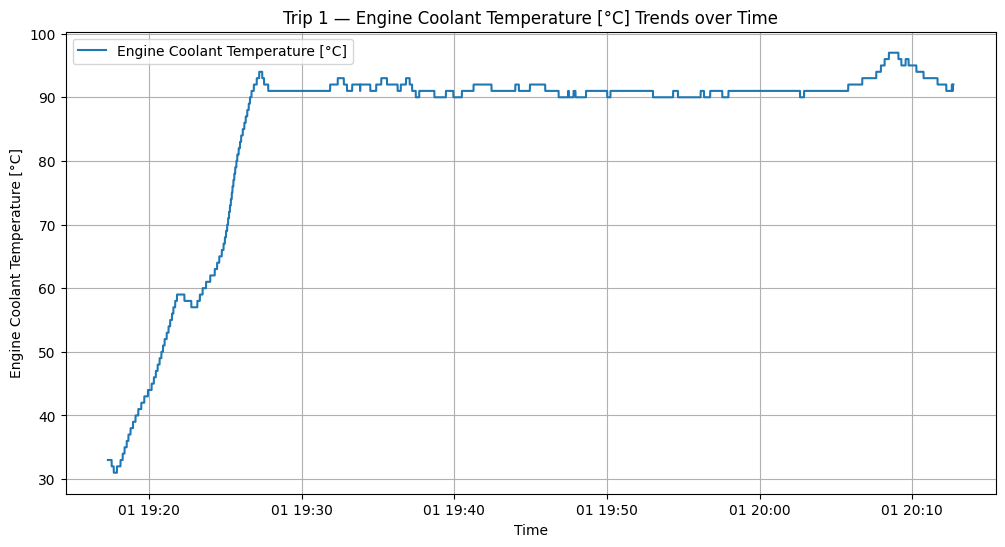

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(df_raw['Time'], df_clean['Engine Coolant Temperature [°C]'], label='Engine Coolant Temperature [°C]')

plt.title("Trip 1 — Engine Coolant Temperature [°C] Trends over Time")
plt.xlabel("Time")
plt.ylabel("Engine Coolant Temperature [°C]")
plt.legend()
plt.grid(True)
plt.show()


In [26]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def plot_all_features_separately(df_clean, df_raw, features=BACKBONE_FEATURES, smoothing=None):
    """
    One subplot per feature (raw, before scaling).
    smoothing: int window size for rolling mean (e.g., 5) or None for no smoothing.
    """
    t = df_raw['elapsed_s'] if 'elapsed_s' in df_raw.columns else np.arange(len(df_clean))
    n = len(features)
    rows = 4
    cols = 2
    plt.figure(figsize=(14, 10))
    for i, f in enumerate(features, start=1):
        if i > rows*cols: break
        y = df_clean[f].copy()
        if smoothing and smoothing > 1:
            y = pd.Series(y).rolling(window=smoothing, center=True, min_periods=1).mean().values
        ax = plt.subplot(rows, cols, i)
        ax.plot(t, y)
        ax.set_title(f)
        ax.grid(True)
        if i > (rows-1)*cols:
            ax.set_xlabel("Elapsed time (s)")
    plt.tight_layout()
    plt.show()


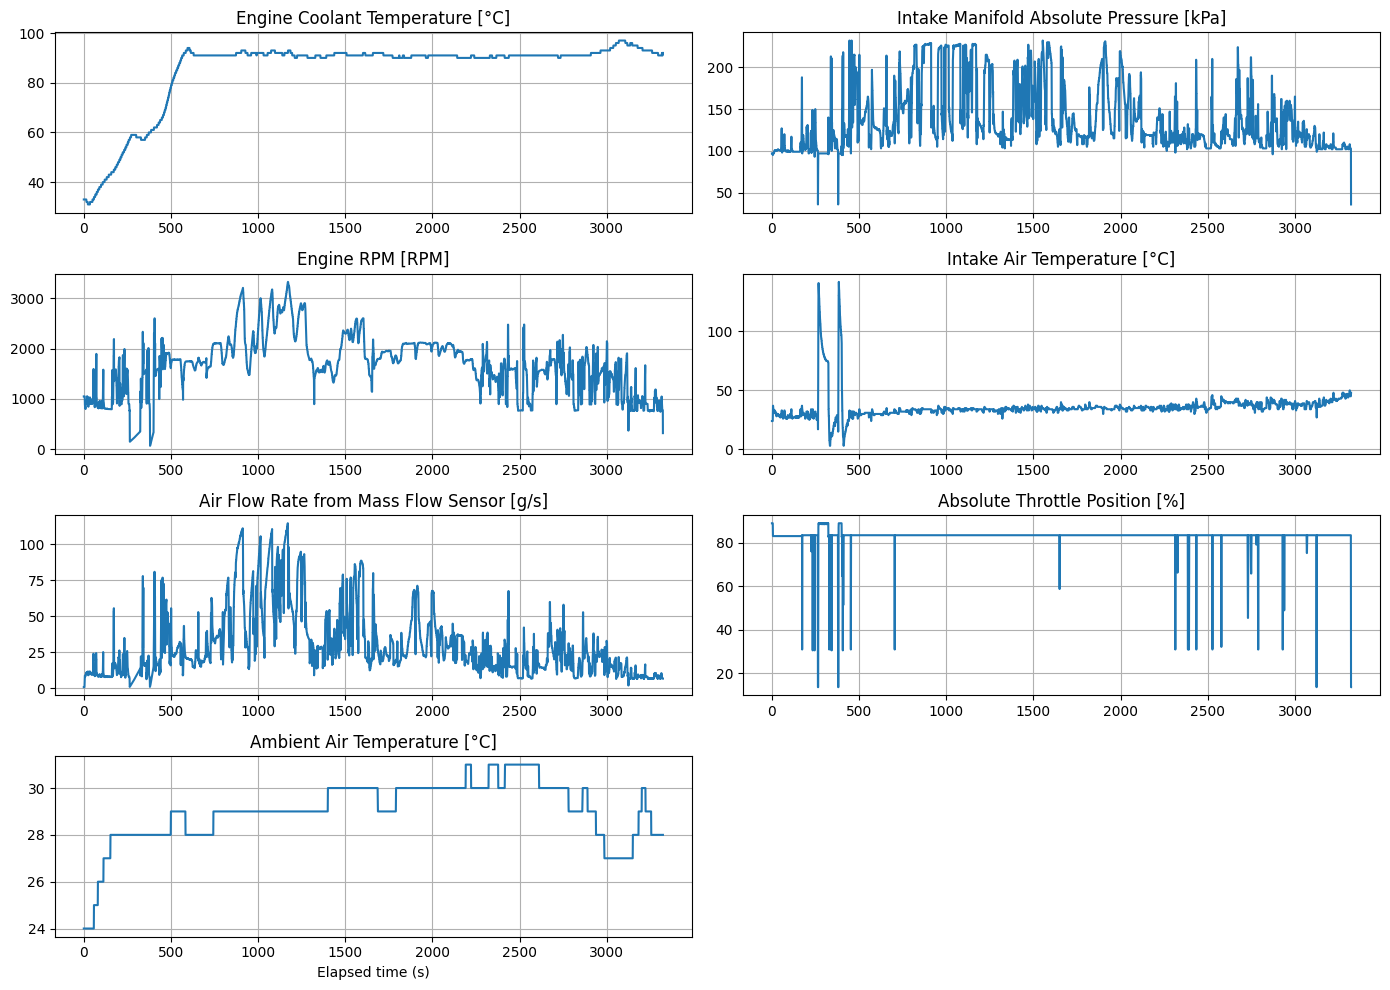

In [24]:

plot_all_features_separately(df_clean, df_raw,BACKBONE_FEATURES, smoothing=5)  # smoothing is optional




In [27]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np

def plot_combustion_trends(df_clean, df_raw):
    # choose time base
    t = df_raw['elapsed_s'] if 'elapsed_s' in df_raw.columns else np.arange(len(df_clean))

    # features
    rpm = df_clean["Engine RPM [RPM]"].values
    throttle = df_clean["Absolute Throttle Position [%]"].values
    map_kpa = df_clean["Intake Manifold Absolute Pressure [kPa]"].values
    maf = df_clean["Air Flow Rate from Mass Flow Sensor [g/s]"].values
    iat = df_clean["Intake Air Temperature [°C]"].values

    # choose a vivid color map
    cmap = mpl.colormaps.get_cmap("tab10")

    plt.figure(figsize=(12, 8))

    # A) Load dynamics (RPM & Throttle)
    ax1 = plt.subplot(3, 1, 1)
    ax1.plot(t, rpm, color=cmap(0), linewidth=1.6, label="RPM")
    ax1.plot(t, throttle, color=cmap(1), linewidth=1.6, label="Throttle (%)")
    ax1.set_title("Combustion – Load Dynamics (RPM vs Throttle)")
    ax1.set_ylabel("Value")
    ax1.legend()
    ax1.grid(True)

    # B) Intake dynamics (MAP & MAF)
    ax2 = plt.subplot(3, 1, 2)
    ax2.plot(t, map_kpa, color=cmap(2), linewidth=1.6, label="MAP (kPa)")
    ax2.plot(t, maf, color=cmap(3), linewidth=1.6, label="MAF (g/s)")
    ax2.set_title("Combustion – Intake Dynamics (MAP vs MAF)")
    ax2.set_ylabel("Value")
    ax2.legend()
    ax2.grid(True)

    # C) Intake Air Temperature
    ax3 = plt.subplot(3, 1, 3)
    ax3.plot(t, iat, color=cmap(4), linewidth=1.6, label="IAT (°C)")
    ax3.set_title("Combustion – Intake Air Temperature (IAT)")
    ax3.set_xlabel("Elapsed time (s)")
    ax3.set_ylabel("°C")
    ax3.legend()
    ax3.grid(True)

    plt.tight_layout()
    plt.show()


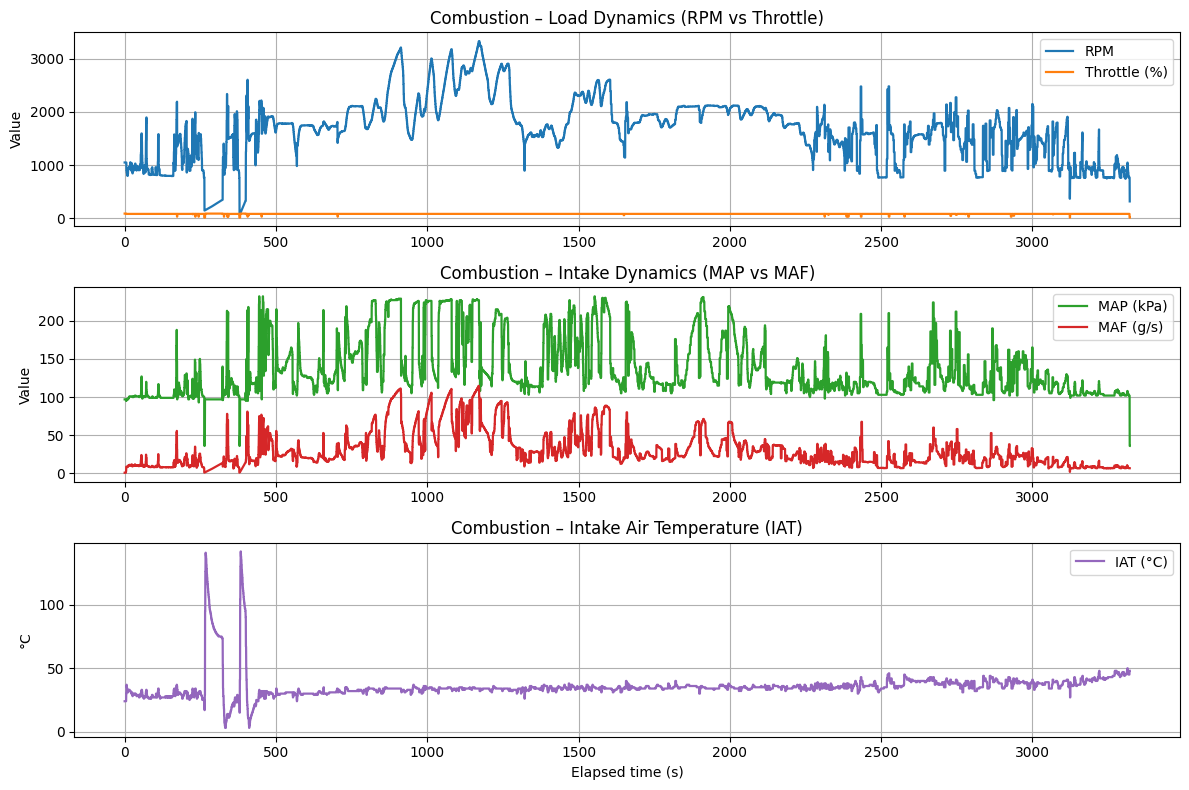

Printing trends for first 500 seconds only:


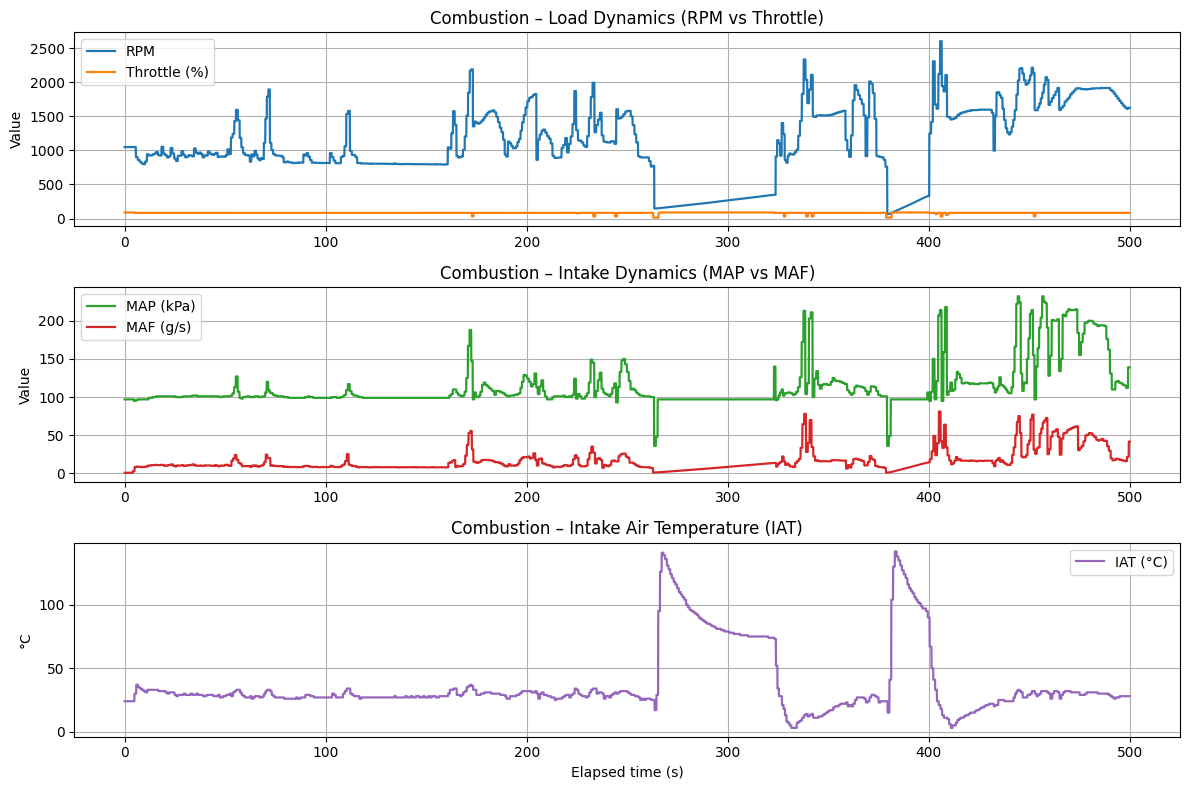

In [26]:
plot_combustion_trends(df_clean, df_raw)
print("Printing trends for first 500 seconds only:")
subset = df_raw[df_raw['elapsed_s'] <= 500]
plot_combustion_trends(df_clean.loc[subset.index], subset)


In [28]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np

def plot_overheating_trends(df_clean, df_raw):
    # Choose time base
    t = df_raw['elapsed_s'] if 'elapsed_s' in df_raw.columns else np.arange(len(df_clean))

    ect = df_clean["Engine Coolant Temperature [°C]"].values
    amb = df_clean["Ambient Air Temperature [°C]"].values
    rpm = df_clean["Engine RPM [RPM]"].values

    # ΔT and dT/dt
    delta_T = ect - amb
    if 'elapsed_s' in df_raw.columns:
        dt = np.gradient(t)
        dt = np.gradient(t)
        dt[dt == 0] = 1e-6  # avoid divide-by-zero
        dTdt = np.gradient(ect, dt)
        dTdt = np.nan_to_num(dTdt, nan=0.0, posinf=0.0, neginf=0.0)  # clean infinities

        
    else:
        dTdt = np.gradient(ect)       # unitless per sample

    # Distinct colors from tab10 palette
    cmap = mpl.colormaps.get_cmap("tab10")

    plt.figure(figsize=(12, 10))

    # A) Coolant vs Ambient + ΔT
    ax1 = plt.subplot(3, 1, 1)
    ax1.plot(t, ect, color=cmap(0), linewidth=1.6, label="Coolant (°C)")
    ax1.plot(t, amb, color=cmap(1), linewidth=1.6, label="Ambient (°C)")
    ax1.plot(t, delta_T, color=cmap(2), linestyle="--", linewidth=1.6, label="ΔT = Coolant − Ambient")
    ax1.set_title("Overheating – Coolant vs Ambient & ΔT")
    ax1.set_ylabel("Temperature (°C)")
    ax1.legend()
    ax1.grid(True)

    # B) Coolant rate of change (dT/dt)
    ax2 = plt.subplot(3, 1, 2)
    ax2.plot(t, dTdt, color=cmap(3), linewidth=1.6, label="dT/dt (°C/s)")
    ax2.set_title("Overheating – Coolant Heating/Cooling Rate")
    ax2.set_ylabel("°C/s")
    ax2.legend()
    ax2.grid(True)

    # C) Coolant vs RPM
    ax3 = plt.subplot(3, 1, 3)
    ax3.plot(t, ect, color=cmap(0), linewidth=1.6, label="Coolant (°C)")
    ax3.plot(t, rpm, color=cmap(4), linewidth=1.6, label="RPM")
    ax3.set_title("Overheating – Coolant vs RPM (Pump/Load Relation)")
    ax3.set_xlabel("Elapsed time (s)")
    ax3.set_ylabel("Value")
    ax3.legend()
    ax3.grid(True)

    plt.tight_layout()
    plt.show()


/usr/local/lib/python3.11/dist-packages/numpy/lib/function_base.py:1242: RuntimeWarning: divide by zero encountered in divide
  a = -(dx2)/(dx1 * (dx1 + dx2))
/usr/local/lib/python3.11/dist-packages/numpy/lib/function_base.py:1242: RuntimeWarning: invalid value encountered in divide
  a = -(dx2)/(dx1 * (dx1 + dx2))
/usr/local/lib/python3.11/dist-packages/numpy/lib/function_base.py:1243: RuntimeWarning: divide by zero encountered in divide
  b = (dx2 - dx1) / (dx1 * dx2)
/usr/local/lib/python3.11/dist-packages/numpy/lib/function_base.py:1243: RuntimeWarning: invalid value encountered in divide
  b = (dx2 - dx1) / (dx1 * dx2)
/usr/local/lib/python3.11/dist-packages/numpy/lib/function_base.py:1244: RuntimeWarning: divide by zero encountered in divide
  c = dx1 / (dx2 * (dx1 + dx2))
/usr/local/lib/python3.11/dist-packages/numpy/lib/function_base.py:1244: RuntimeWarning: invalid value encountered in divide
  c = dx1 / (dx2 * (dx1 + dx2))
/usr/local/lib/python3.11/dist-packages/numpy/lib/fun

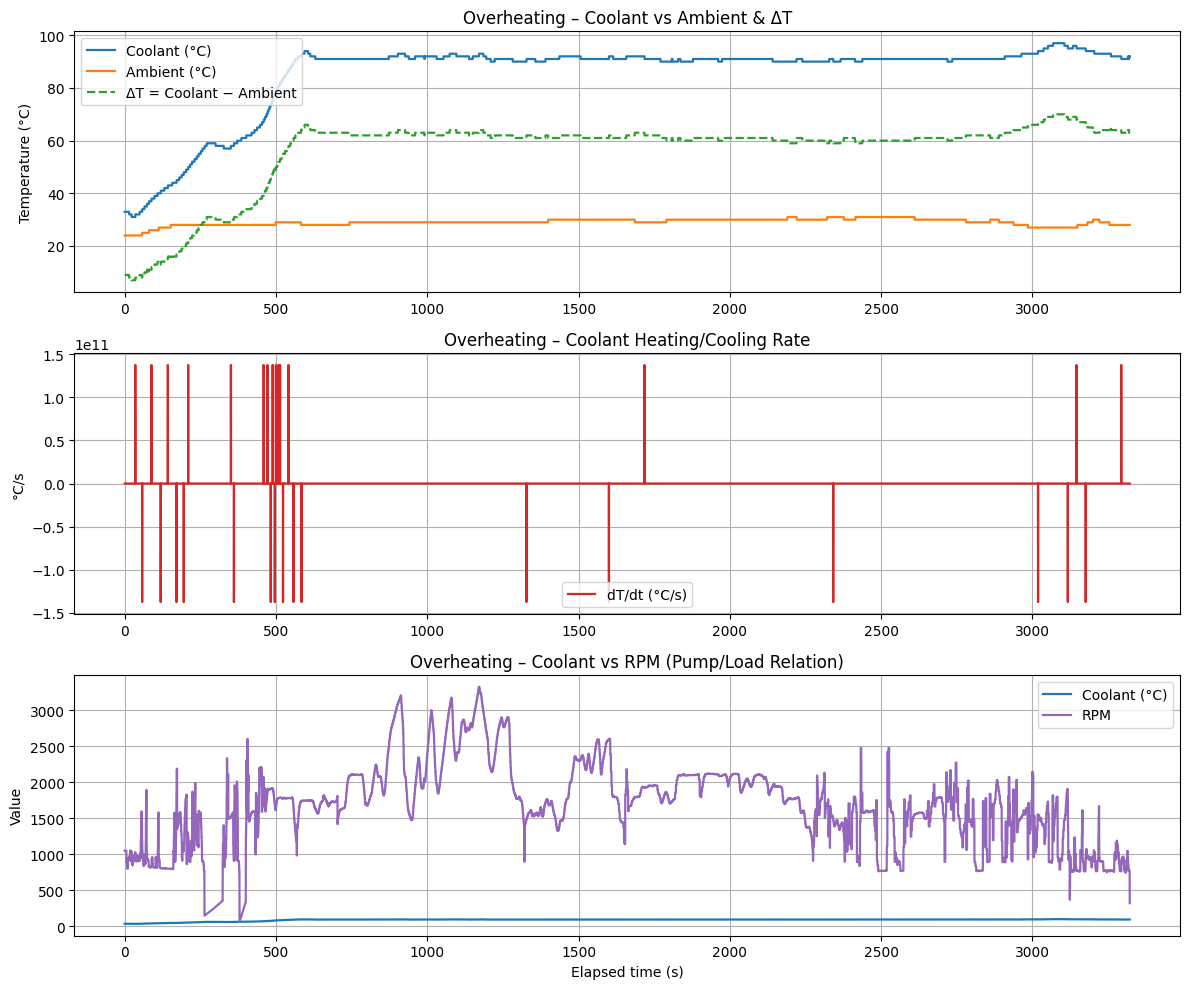

In [29]:
plot_overheating_trends(df_clean, df_raw)


**LSTM with one shared backbbone**

In [30]:
import numpy as np
from sklearn.model_selection import train_test_split

# all_trips: list of arrays, each (num_seq_i, SEQ_LEN, n_features)
num_trips = len(all_trips)
trip_indices = np.arange(num_trips)

# 70% train, 15% val, 15% test (by trips)
train_idx, holdout_idx = train_test_split(
    trip_indices, test_size=0.30, random_state=42, shuffle=True
)
val_idx, test_idx = train_test_split(
    holdout_idx, test_size=0.50, random_state=42, shuffle=True
)

def concat_trips(idxs):
    parts = [all_trips[i] for i in idxs if len(all_trips[i]) > 0]
    return np.concatenate(parts, axis=0) if parts else np.empty((0, SEQ_LEN, len(BACKBONE_FEATURES)))

X_train = concat_trips(train_idx)
X_val   = concat_trips(val_idx)
X_test_normal = concat_trips(test_idx)

print("Trips -> counts:", len(train_idx), len(val_idx), len(test_idx))
print("X_train:", X_train.shape, "| X_val:", X_val.shape, "| X_test_normal:", X_test_normal.shape)


Trips -> counts: 56 12 13
X_train: (376266, 50, 7) | X_val: (74347, 50, 7) | X_test_normal: (87373, 50, 7)


In [30]:
from tensorflow.keras import Model, Input
from tensorflow.keras.layers import LSTM, Dense, RepeatVector, TimeDistributed

seq_len, n_features = 50, len(BACKBONE_FEATURES)
inputs = Input(shape=(seq_len, n_features))

# Encoder
x = LSTM(128, activation='relu', return_sequences=True)(inputs)
x = LSTM(64, activation='relu', return_sequences=False)(x)
latent = Dense(32, activation='relu')(x)

# Decoder
x = RepeatVector(seq_len)(latent)
x = LSTM(64, activation='relu', return_sequences=True)(x)
x = LSTM(128, activation='relu', return_sequences=True)(x)
reconstructed = TimeDistributed(Dense(n_features))(x)

# Model
model = Model(inputs, reconstructed)
model.compile(optimizer='adam', loss='mse')
model.summary()


I0000 00:00:1760812483.175488      37 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1760812483.176201      37 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 50, 7)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 50, 128)        │        69,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector (RepeatVector)    │ (None, 50, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 50, 64)         │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 50, 128)        │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 50, 7)          │           903 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 245,671 (959.65 KB)

 Trainable params: 245,671 (959.65 KB)

 Non-trainable params: 0 (0.00 B)

In [31]:
print(X_train.shape, X_val.shape)


(376266, 50, 7) (74347, 50, 7)


In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# callbacks to prevent overfitting and save best model
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=8,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    'lstm_autoencoder_best.h5',
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

history = model.fit(
    X_train, X_train,                   # reconstruction task
    epochs=80,
    batch_size=64,
    validation_data=(X_val, X_val),
    callbacks=[early_stop, checkpoint],
    verbose=1
)


Epoch 1/80


I0000 00:00:1760812508.622232     110 service.cc:148] XLA service 0x59cfed40 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1760812508.623884     110 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1760812508.623906     110 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1760812509.909717     110 cuda_dnn.cc:529] Loaded cuDNN version 90300


   3/5880 ━━━━━━━━━━━━━━━━━━━━ 4:04 42ms/step - loss: 0.3171   

I0000 00:00:1760812519.022153     110 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


5880/5880 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0121
Epoch 1: val_loss improved from inf to 0.00098, saving model to lstm_autoencoder_best.h5
5880/5880 ━━━━━━━━━━━━━━━━━━━━ 151s 22ms/step - loss: 0.0121 - val_loss: 9.7677e-04
Epoch 2/80
5878/5880 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 6.8493e-04
Epoch 2: val_loss improved from 0.00098 to 0.00061, saving model to lstm_autoencoder_best.h5
5880/5880 ━━━━━━━━━━━━━━━━━━━━ 122s 21ms/step - loss: 6.8490e-04 - val_loss: 6.0912e-04
Epoch 3/80
5878/5880 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 4.7719e-04
Epoch 3: val_loss improved from 0.00061 to 0.00043, saving model to lstm_autoencoder_best.h5
5880/5880 ━━━━━━━━━━━━━━━━━━━━ 122s 21ms/step - loss: 4.7717e-04 - val_loss: 4.2761e-04
Epoch 4/80
5878/5880 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 3.6967e-04
Epoch 4: val_loss did not improve from 0.00043
5880/5880 ━━━━━━━━━━━━━━━━━━━━ 122s 21ms/step - loss: 3.6967e-04 - val_loss: 4.2906e-04
Epoch 5/80
5878/5880 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms

In [31]:
np.savez_compressed(
    "/kaggle/working/preprocessed_data.npz",
    X_train=X_train, X_val=X_val, X_test_normal=X_test_normal,
    BACKBONE_FEATURES=BACKBONE_FEATURES
)


In [39]:
model.save("/kaggle/working/lstm_autoencoder_best.keras")


In [41]:
model = load_model("/kaggle/working/lstm_autoencoder_best.keras")


/usr/local/lib/python3.11/dist-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'adam', because it has 34 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


**SYNTHETIC TEST SET**

In [65]:
# 1) Errors on normal validation windows
Xhat_val = model.predict(X_val, verbose=0)
val_err = ((X_val - Xhat_val)**2).mean(axis=(1,2))

# 2) Pick quantile threshold(s)
thr_p95 = np.percentile(val_err, 95)   # more sensitive
thr_p96 = np.percentile(val_err, 96)   
thr_p97 = np.percentile(val_err, 97)   
thr_p98 = np.percentile(val_err, 98)
thr_p99 = np.percentile(val_err, 99)   # stricter
   


print(f"95th percentile: {thr_p95:.6f}")
print(f"96th percentile: {thr_p96:.6f}")
print(f"97th percentile: {thr_p97:.6f}")
print(f"98th percentile: {thr_p98:.6f}")

print(f"99th percentile: {thr_p99:.6f}")


95th percentile: 0.000304
96th percentile: 0.000372
97th percentile: 0.000477
98th percentile: 0.000670
99th percentile: 0.001103


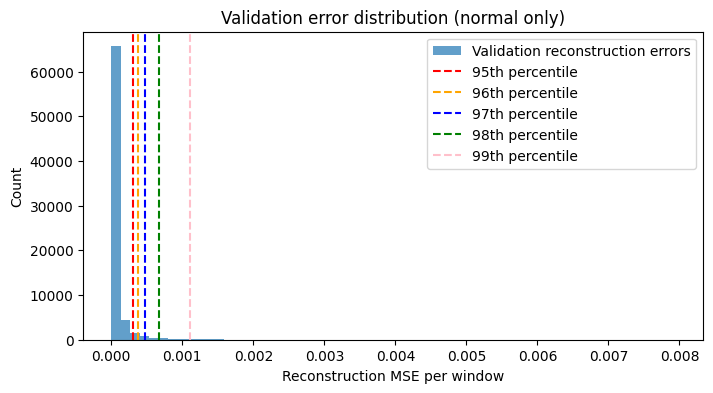

In [43]:


plt.figure(figsize=(8,4))
plt.hist(val_err, bins=60, alpha=0.7, label='Validation reconstruction errors')
plt.axvline(thr_p95, color='r', linestyle='--', label='95th percentile')
plt.axvline(thr_p96, color='orange', linestyle='--', label='96th percentile')
plt.axvline(thr_p97, color='blue', linestyle='--', label='97th percentile')
plt.axvline(thr_p98, color='green', linestyle='--', label='98th percentile')

plt.axvline(thr_p99, color='pink', linestyle='--', label='99th percentile')
plt.xlabel("Reconstruction MSE per window")
plt.ylabel("Count")
plt.legend()
plt.title("Validation error distribution (normal only)")
plt.show()


In [44]:
ae_features = BACKBONE_FEATURES  
f2i = {f:i for i,f in enumerate(ae_features)}
i_cool = f2i["Engine Coolant Temperature [°C]"]
i_rpm  = f2i["Engine RPM [RPM]"]
i_map  = f2i["Intake Manifold Absolute Pressure [kPa]"]
i_maf  = f2i["Air Flow Rate from Mass Flow Sensor [g/s]"]
i_thr  = f2i["Absolute Throttle Position [%]"]
i_iat  = f2i["Intake Air Temperature [°C]"]
i_amb  = f2i["Ambient Air Temperature [°C]"]


In [57]:
import numpy as np

def add_overheat_only(X, i_cool, frac=0.15, delta=0.25, span_frac=0.60, seed=123):
    """
    Inject synthetic overheating behavior:
    - Selects a subset of windows (frac)
    - Gradually increases coolant temperature within a time span
    - Clipped between [0, 1] since data is MinMax scaled
    """
    rng = np.random.default_rng(seed)
    Xo = X.copy()
    N, T, _ = Xo.shape

    # pick random windows to corrupt
    idx = rng.choice(N, size=int(frac * N), replace=False)

    for i in idx:
        # pick contiguous region of overheating within the window
        span = int(span_frac * T)
        t0 = rng.integers(0, T - span)
        t1 = t0 + span

        # create smooth, gradual increase pattern
        ramp = np.linspace(0, delta, span)
        Xo[i, t0:t1, i_cool] = np.clip(Xo[i, t0:t1, i_cool] + ramp, 0, 1)

    np.clip(Xo, 0.0, 1.0, out=Xo)
    y = np.ones(len(idx), int)
    return Xo[idx], idx, y


In [58]:
# Find index of Coolant Temp
i_cool = BACKBONE_FEATURES.index("Engine Coolant Temperature [°C]")

# Apply overheating injection to normal test samples
X_overheat, idx, y_overheat = add_overheat_only(
    X_test_normal,
    i_cool=i_cool,
    frac=0.15,       # inject into 15% of windows
    delta=0.25,      # 25% of full-scale rise in normalized scale
    span_frac=0.6,   # heating occurs over 60% of window length
    seed=42
)

# Equal number of normal windows for fair comparison
rng = np.random.default_rng(2025)
idx_norm = rng.choice(len(X_test_normal), size=len(X_overheat), replace=False)
X_norm = X_test_normal[idx_norm]
y_norm = np.zeros(len(X_norm), int)

# Combine and shuffle
X_test = np.concatenate([X_norm, X_overheat], axis=0)
y_test = np.concatenate([y_norm, y_overheat], axis=0)
perm = rng.permutation(len(X_test))
X_test, y_test = X_test[perm], y_test[perm]

print("X_test:", X_test.shape)
print("Anomalies (Overheat):", y_test.sum())


X_test: (26210, 50, 7)
Anomalies (Overheat): 13105


In [66]:
np.savez_compressed(
    "/kaggle/working/test_data.npz",
    X_test=X_test,y_test=y_test,

)


In [62]:


# pick threshold from validation error distribution (you should have done this earlier)
# threshold = np.percentile(val_err, 95)
Xhat_test = model.predict(X_test)
test_err = ((X_test - Xhat_test)**2).mean(axis=(1,2))
y_pred = (test_err > thr_p95).astype(int)

from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred, digits=3))


820/820 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step
              precision    recall  f1-score   support

           0      0.963     0.970     0.966     13105
           1      0.970     0.962     0.966     13105

    accuracy                          0.966     26210
   macro avg      0.966     0.966     0.966     26210
weighted avg      0.966     0.966     0.966     26210



[[12712   393]
 [  493 12612]]


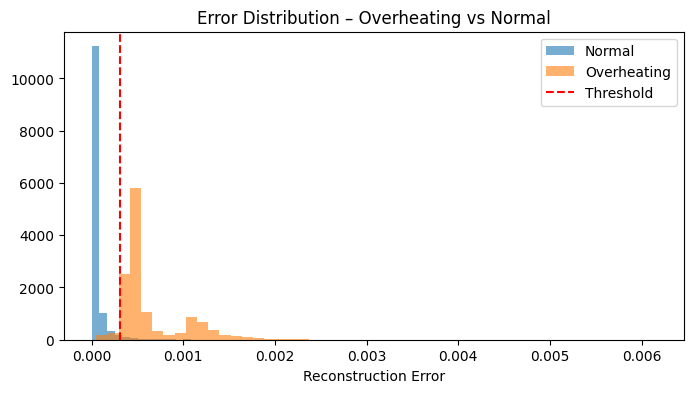

In [64]:
from sklearn.metrics import classification_report, confusion_matrix
print(confusion_matrix(y_test, y_pred))
plt.figure(figsize=(8,4))
plt.hist(test_err[y_test==0], bins=50, alpha=0.6, label='Normal')
plt.hist(test_err[y_test==1], bins=50, alpha=0.6, label='Overheating')
plt.axvline(thr_p95, color='r', linestyle='--', label='Threshold')
plt.legend(); plt.xlabel('Reconstruction Error'); plt.title('Error Distribution – Overheating vs Normal')
plt.show()

In [69]:
import joblib

# assuming your scaler is already fit
joblib.dump(scaler, "scaler.pkl")

print(" Scaler saved as scaler.pkl")


 Scaler saved as scaler.pkl


In [70]:
import numpy as np

np.save("threshold.npy", thr_p95)
print(" Threshold saved as threshold.npy")


 Threshold saved as threshold.npy


In [71]:
threshold = np.load("/kaggle/working/threshold.npy")
scaler=joblib.load("/kaggle/working/scaler.pkl")




In [72]:
def generalized_overheat_diagnosis(df):
    reasons = []
    ECT = df["Engine Coolant Temperature [°C]"].mean()
    AAT = df["Ambient Air Temperature [°C]"].mean()
    RPM = df["Engine RPM [RPM]"].mean()
    THR = df["Absolute Throttle Position [%]"].mean()
    IAT = df["Intake Air Temperature [°C]"].mean()
    MAP = df["Intake Manifold Absolute Pressure [kPa]"].mean()
    MAF = df["Air Flow Rate from Mass Flow Sensor [g/s]"].mean()
    ΔT = ECT - AAT

    if ECT > 100: reasons.append("Coolant temperature exceeds 100 °C — possible cooling system overload.")
    if ΔT > 70: reasons.append("ΔT > 70 °C — radiator or coolant circulation inefficiency.")
    if ECT > 100 and RPM < 1000: reasons.append("High ECT at idle — radiator fan or water pump malfunction likely.")
    if ECT > 100 and THR < 10: reasons.append("Overheating under low throttle — thermostat or coolant blockage.")
    if IAT - AAT > 15: reasons.append("Intake air unusually hot — airflow restriction or engine bay heat soak.")
    if MAP < 80: reasons.append("Low manifold pressure — possible intake restriction or vacuum leak.")
    if MAF < 3: reasons.append("Low air flow rate — check air filter or MAF sensor.")
    if not reasons:
        reasons.append("No rule violations detected — temperature within normal range.")
    return reasons


In [73]:
import numpy as np
import pandas as pd

BACKBONE_FEATURES = [
    "Engine Coolant Temperature [°C]",
    "Intake Manifold Absolute Pressure [kPa]",
    "Engine RPM [RPM]",
    "Intake Air Temperature [°C]",
    "Air Flow Rate from Mass Flow Sensor [g/s]",
    "Absolute Throttle Position [%]",
    "Ambient Air Temperature [°C]",
]

# ---- Normal window (healthy engine)
data_normal = {
    "Engine Coolant Temperature [°C]": np.linspace(85, 95, 50),  # stable within range
    "Intake Manifold Absolute Pressure [kPa]": np.linspace(95, 100, 50),
    "Engine RPM [RPM]": np.linspace(900, 2500, 50),
    "Intake Air Temperature [°C]": np.linspace(35, 40, 50),
    "Air Flow Rate from Mass Flow Sensor [g/s]": np.linspace(5, 15, 50),
    "Absolute Throttle Position [%]": np.linspace(10, 30, 50),
    "Ambient Air Temperature [°C]": np.linspace(30, 35, 50),
}
df_normal = pd.DataFrame(data_normal)

# ---- Faulty window (simulated overheating)
data_faulty = {
    "Engine Coolant Temperature [°C]": np.linspace(95, 115, 50),  # abnormally high
    "Intake Manifold Absolute Pressure [kPa]": np.linspace(100, 90, 50),  # slight dip
    "Engine RPM [RPM]": np.linspace(800, 1200, 50),  # idle
    "Intake Air Temperature [°C]": np.linspace(40, 55, 50),  # rising intake temp
    "Air Flow Rate from Mass Flow Sensor [g/s]": np.linspace(6, 10, 50),
    "Absolute Throttle Position [%]": np.linspace(8, 10, 50),
    "Ambient Air Temperature [°C]": np.linspace(30, 32, 50),
}
df_faulty = pd.DataFrame(data_faulty)


In [74]:
from sklearn.preprocessing import MinMaxScaler
import joblib

def preprocess_window(df, scaler, features):
    # ensure column order
    df = df[features].copy()
    # interpolate (if needed)
    df = df.replace(0, np.nan).interpolate().ffill().bfill()
    # scale
    scaled = scaler.transform(df)
    # reshape to (1, seq_len, n_features)
    return np.expand_dims(scaled, axis=0)

X_normal = preprocess_window(df_normal, scaler, BACKBONE_FEATURES)
X_faulty = preprocess_window(df_faulty, scaler, BACKBONE_FEATURES)


In [75]:


def get_recon_error(X, model):
    Xhat = model.predict(X, verbose=0)
    return np.mean((X - Xhat) ** 2)

err_normal = get_recon_error(X_normal, model)
err_faulty = get_recon_error(X_faulty, model)

print(f"Normal window reconstruction error: {err_normal:.6f}")
print(f"Faulty window reconstruction error: {err_faulty:.6f}")


Normal window reconstruction error: 0.002415
Faulty window reconstruction error: 0.003851


In [81]:

def classify_anomaly(err, threshold):
    return "Overheating Detected" if err > threshold else "Normal"

print("Normal window →", classify_anomaly(err_normal, thr_p95))
print("Faulty window →", classify_anomaly(err_faulty, thr_p95))


Normal window → Overheating Detected
Faulty window → Overheating Detected


In [83]:
print("Normal window diagnosis:", generalized_overheat_diagnosis(df_normal))
print("Faulty window diagnosis:", generalized_overheat_diagnosis(df_faulty))


Normal window diagnosis: ['No rule violations detected — temperature within normal range.']
Faulty window diagnosis: ['Coolant temperature exceeds 100 °C — possible cooling system overload.', 'ΔT > 70 °C — radiator or coolant circulation inefficiency.', 'Overheating under low throttle — thermostat or coolant blockage.', 'Intake air unusually hot — airflow restriction or engine bay heat soak.']


In [85]:
def analyze_window(df, label):
    X = preprocess_window(df, scaler, BACKBONE_FEATURES)
    err = get_recon_error(X, model)
    is_anom = err > threshold
    print(f"\n=== {label.upper()} WINDOW ===")
    print(f"Reconstruction error: {err:.6f} | Threshold: {threshold:.6f}")
    print("Status:", " Overheating" if is_anom else " Normal")
    if is_anom:
        print("\nPossible Causes:")
        for reason in generalized_overheat_diagnosis(df):
            print(" -", reason)

analyze_window(df_normal, "Normal")
analyze_window(df_faulty, "Faulty")



=== NORMAL WINDOW ===
Reconstruction error: 0.002415 | Threshold: 0.000304
Status:  Overheating

Possible Causes:
 - No rule violations detected — temperature within normal range.

=== FAULTY WINDOW ===
Reconstruction error: 0.003851 | Threshold: 0.000304
Status:  Overheating

Possible Causes:
 - Coolant temperature exceeds 100 °C — possible cooling system overload.
 - ΔT > 70 °C — radiator or coolant circulation inefficiency.
 - Overheating under low throttle — thermostat or coolant blockage.
 - Intake air unusually hot — airflow restriction or engine bay heat soak.
